# Plot results from searching in data using the zero-latency search

So now we get to the results plotting - this are a bit out-of-order from the paper here as this notebook contains plots from all the runs, both with and without signal removal.

In [ ]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/zero_latency_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_zero_latency as get_results


/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Load in the results - both PSD models, and both with and without signal removal

In [ ]:
times_before = [0.5, 1, 4, 7, 14]


results_model_raw = get_results(
    "results/psd_model/data_runs_raw_{time_before}_results.hdf",
    times_before
)

results_model_remove = get_results(
    "results/psd_model/data_runs_remove_{time_before}_results.hdf",
    times_before
)

results_estimate_raw = get_results(
    "results/psd_estimate/data_runs_raw_{time_before}_results.hdf",
    times_before
)

results_estimate_remove = get_results(
    "results/psd_estimate/data_runs_remove_{time_before}_results.hdf",
    times_before
)

In [ ]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky, _ = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky['CoalescenceTime']

# Full run plots

This is the plot of the analysis without signal removal. even in the full-run plot we can see the secondary peaks, particularly for signals 0, 6 and 10.

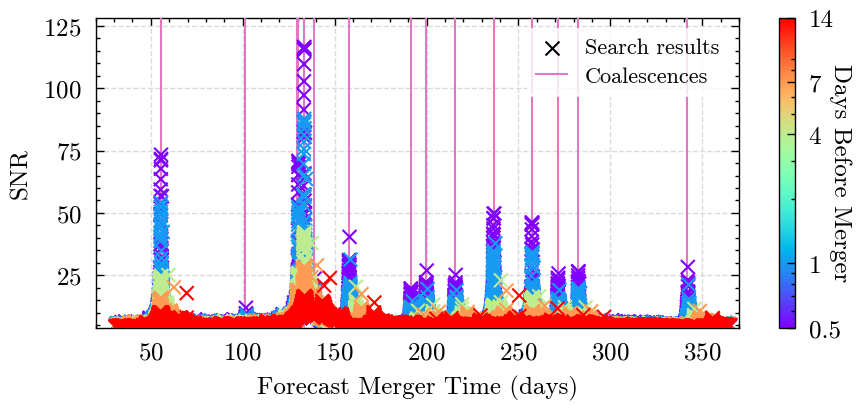

In [ ]:
fig_model_all, _ = plotting_utils.plot_around_time(
    results_one=results_model_raw,
    truth_times=truth_times_s,
    times_before=times_before,
    width_factor=1.5,
    label_one='Search results',
    legend_loc='upper right'
)

## Figure 6

This is the same, but with the mergers removed from the data

### Figure 6

This is the same, but with the mergers removed from the data

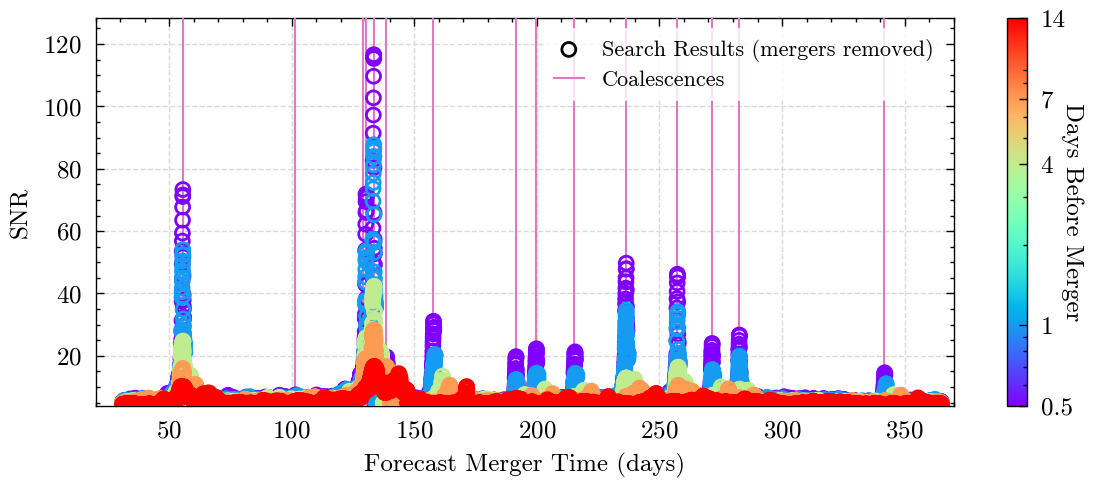

In [ ]:
fig_model_all, _ = plotting_utils.plot_around_time(
    results_one=results_model_remove,
    truth_times=truth_times_s,
    times_before=times_before,
    marker_one='o',
    label_one='Search Results (mergers removed)',
    width_factor=2,
    height_factor=1.25,
    legend_loc='upper right'
)
fig_model_all.savefig(f'{paper_plots_dir}/figure_6_zerolatency_result.png', dpi=300)

Now lets plot them both on the same axis just to compare.

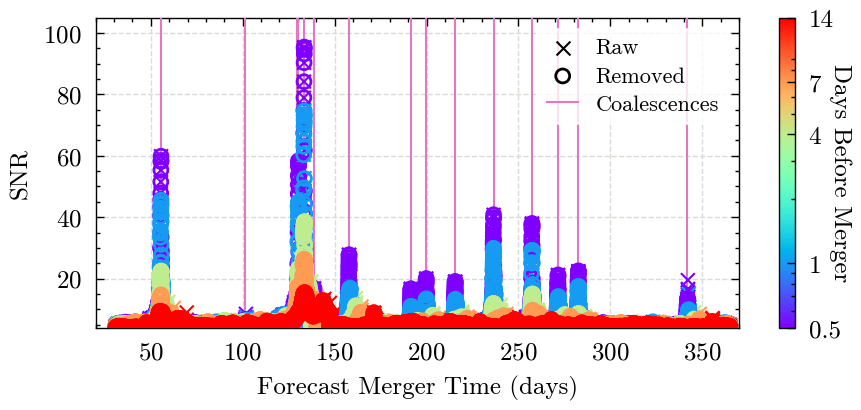

In [ ]:
fig_estimate_all, _ = plotting_utils.plot_around_time(
    results_one=results_estimate_raw,
    results_two=results_estimate_remove,
    truth_times=truth_times_s,
    times_before=times_before,
    width_factor=1.5,
    legend_loc='upper right'
)

This is the example signal shown in figures 4&5, but the raw-only version to start with

# Individual Signal Plots

This is the example signal shown in figures 4&5, but the raw-only version to start with

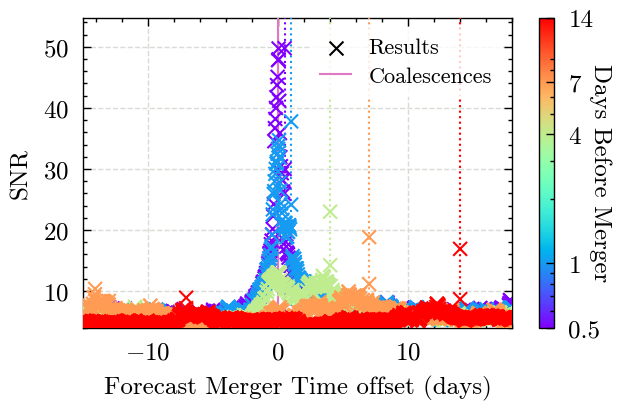

In [ ]:
example_signal_number = 10

fig_model, _ = plotting_utils.plot_around_time(
    results_one=results_model_raw,
    signal_truth_time=truth_times_s[example_signal_number],
    truth_times=truth_times_s,
    start_time_offset=-15,
    end_time_offset=18,
    times_before=times_before,
    signal_number=example_signal_number,
    title='off',
    legend_loc='upper right',
    label_one='Results'
)

## Figure 5

One of the plots from the paper -  a zoom in on Signal 10 so that we see the secondary peaks clearly in the raw results, and that they have been removed in the peak removal instance.

### Figure 5

One of the plots from the paper -  a zoom in on Signal 10 so that we see the secondary peaks clearly in the raw results, and that they have been removed in the peak removal instance.

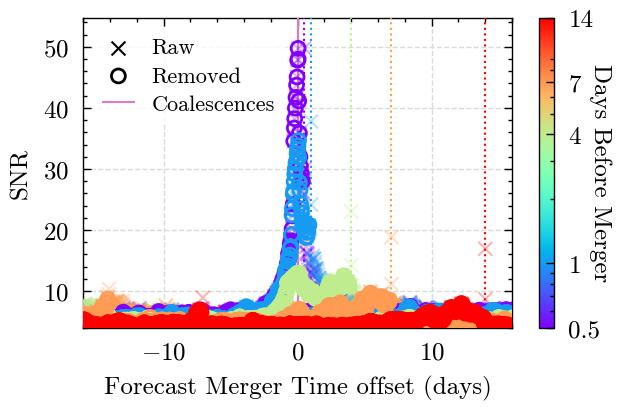

In [ ]:
fig_model, _ = plotting_utils.plot_around_time(
    results_one=results_model_raw,
    results_two=results_model_remove,
    signal_truth_time=truth_times_s[example_signal_number],
    truth_times=truth_times_s,
    start_time_offset=-16,
    end_time_offset=16,
    times_before=times_before,
    signal_number=example_signal_number,
    title='off',
    legend_loc='upper left',
    alpha_one=0.3
)
fig_model.savefig(f'{paper_plots_dir}/figure_5_signal_{example_signal_number}_removed.pdf')

For completeness - make the plot for all the signals

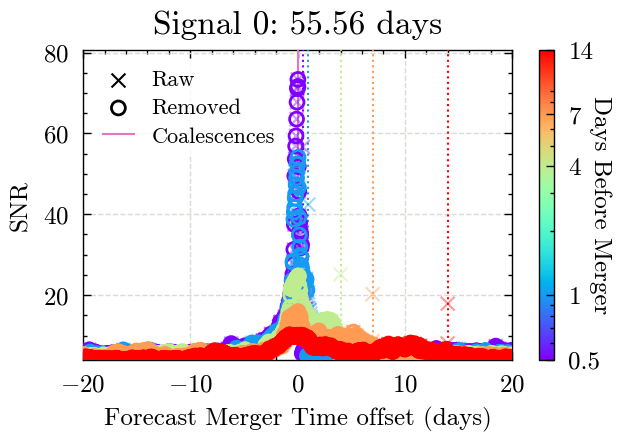

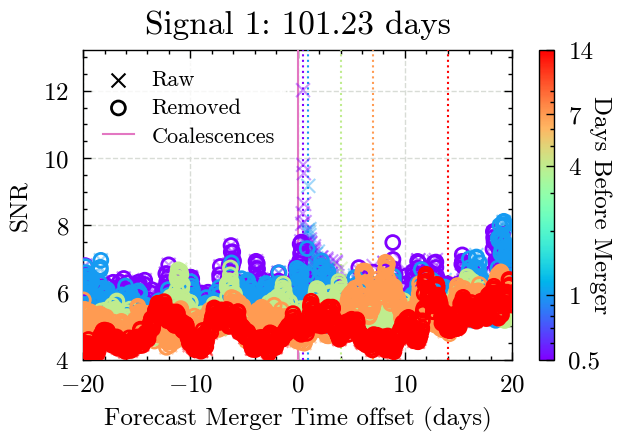

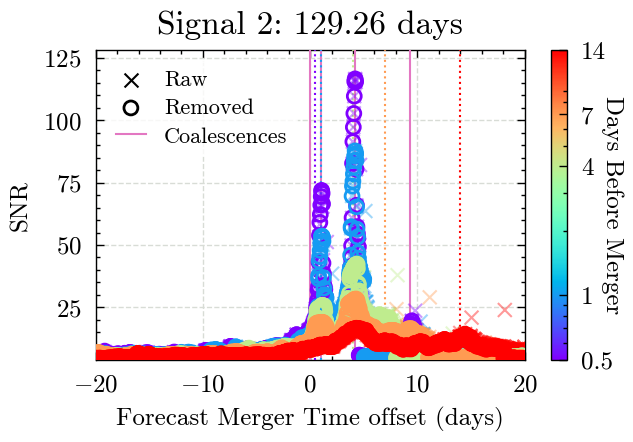

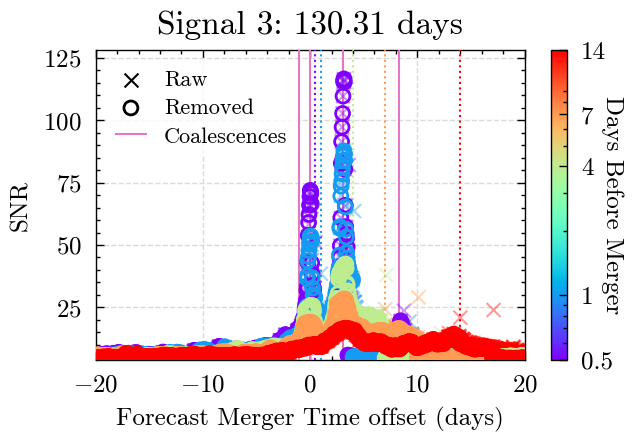

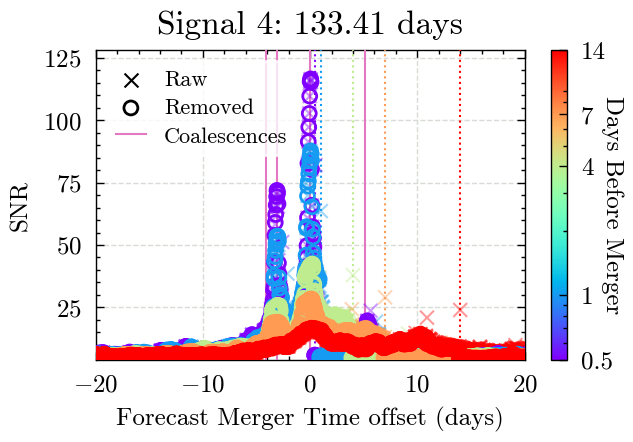

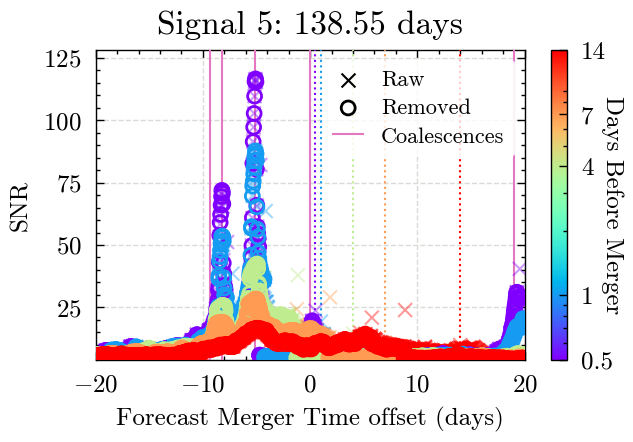

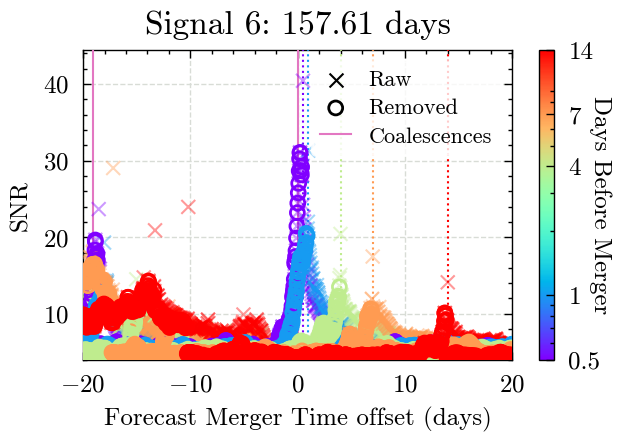

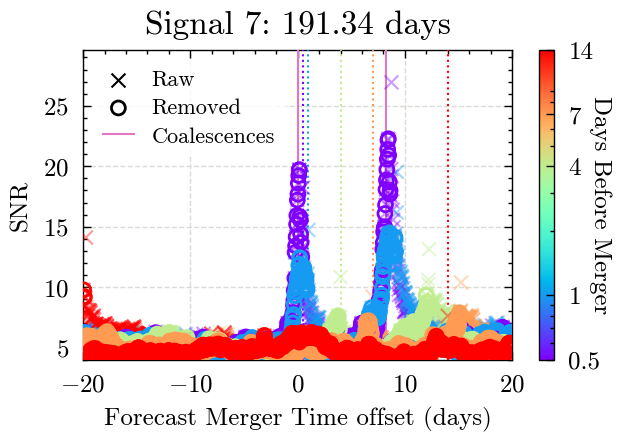

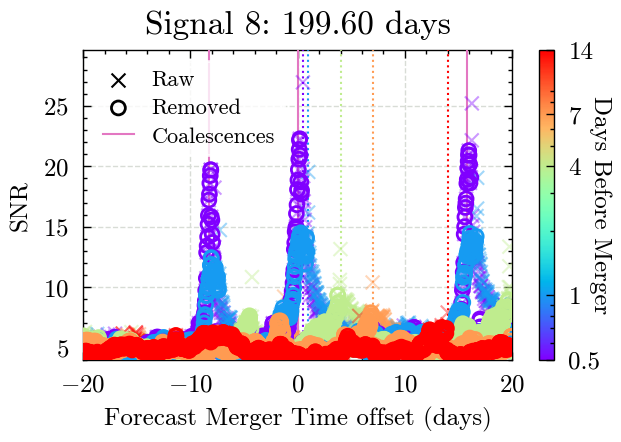

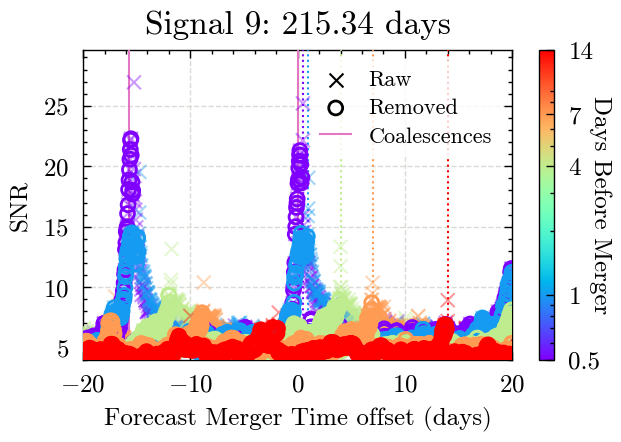

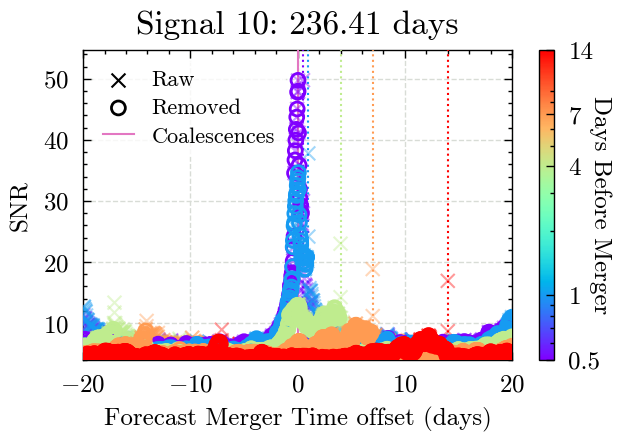

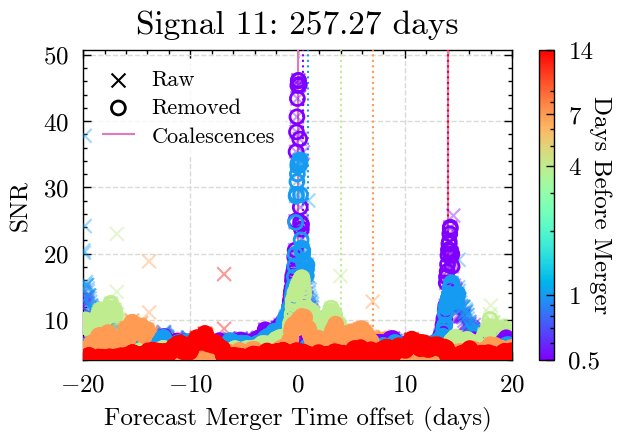

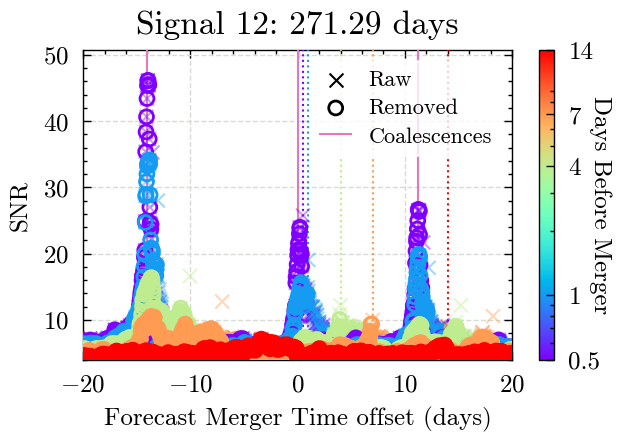

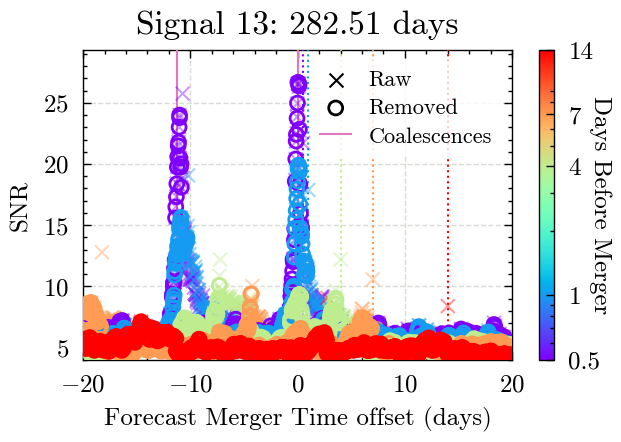

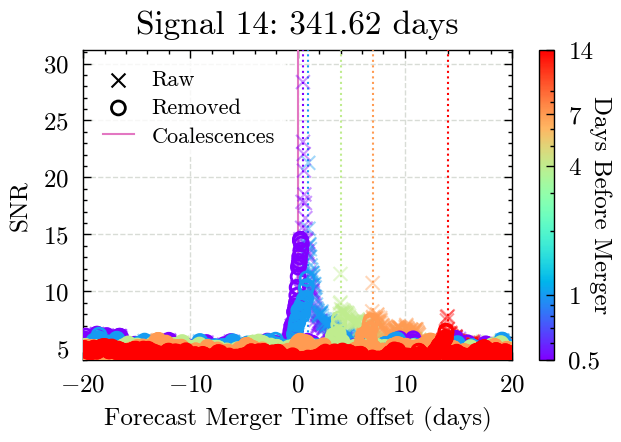

In [ ]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_model, _ = plotting_utils.plot_around_time(
        results_one=results_model_raw,
        results_two=results_model_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-20,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i,
        legend_loc='upper right' if i in [5,6,9,12,13] else 'upper left',
        alpha_one=0.4
    )

## Data end time plots

Now make the plots, but this time, use the data end time on the x-axis rather than the forecast merger time. This allows us to see some other features.

### Data end time plots

Now make the plots, but this time, use the data end time on the x-axis rather than the forecast merger time. This allows us to see some other features.

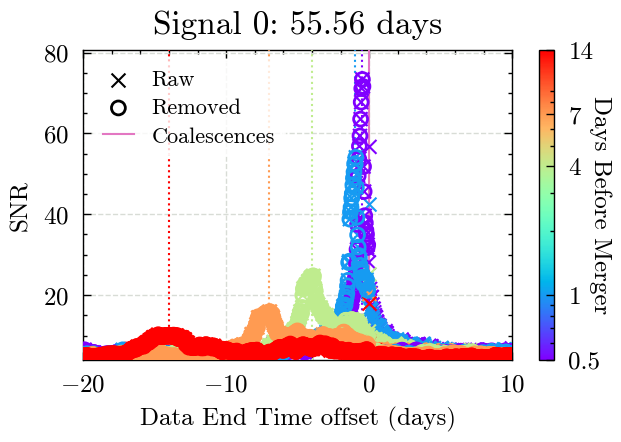

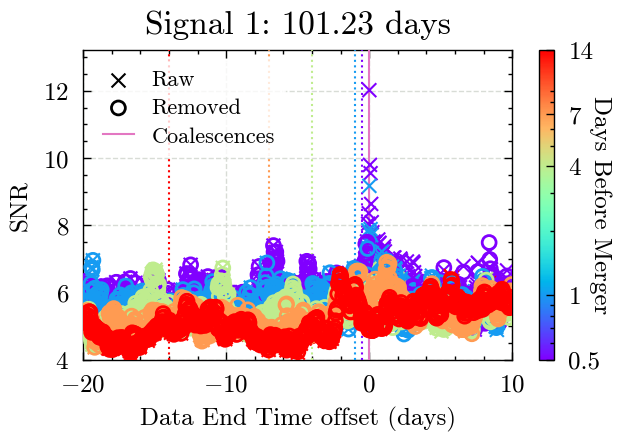

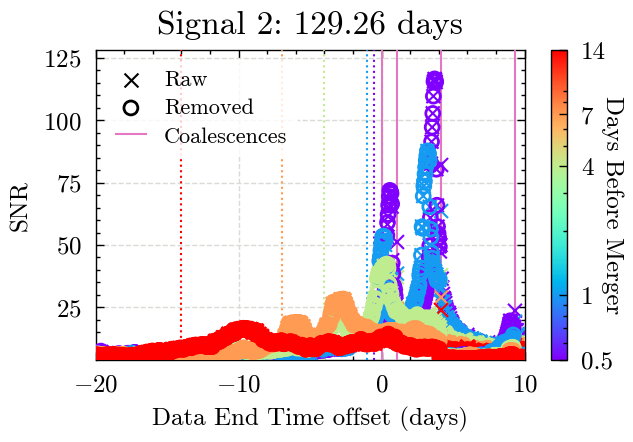

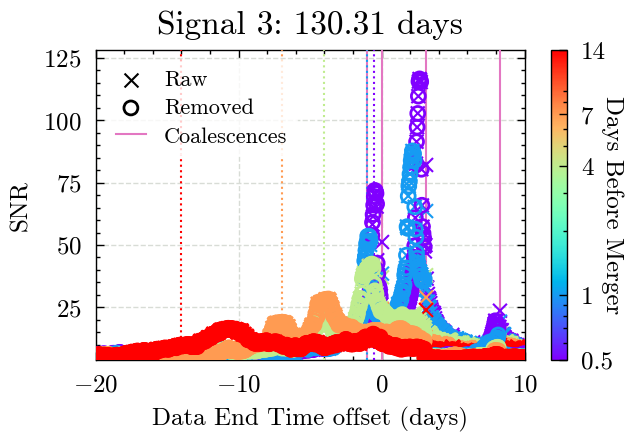

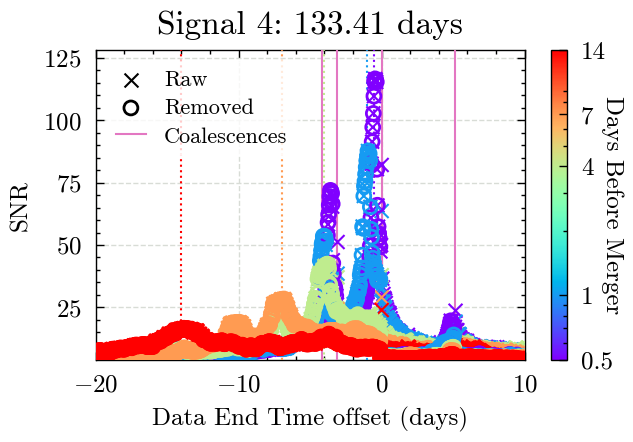

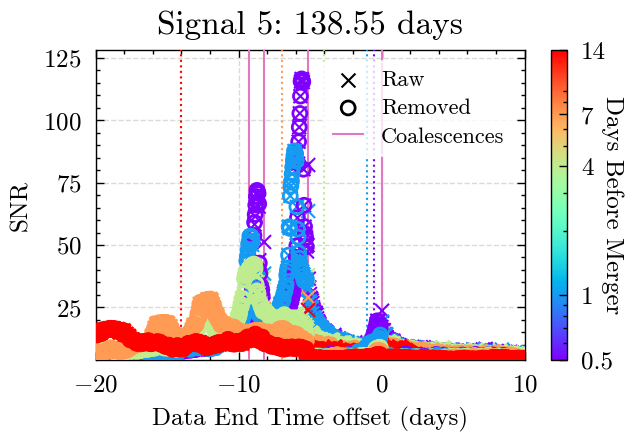

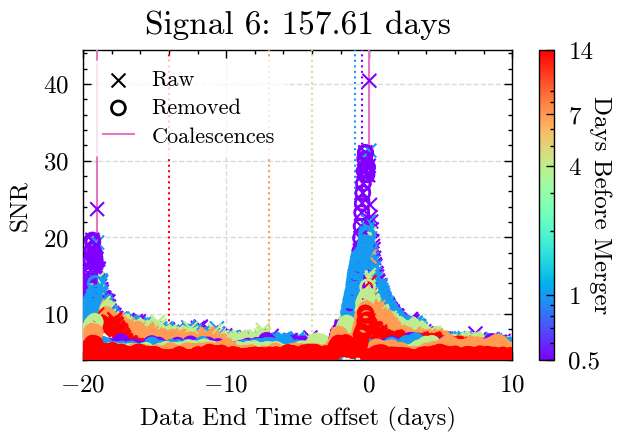

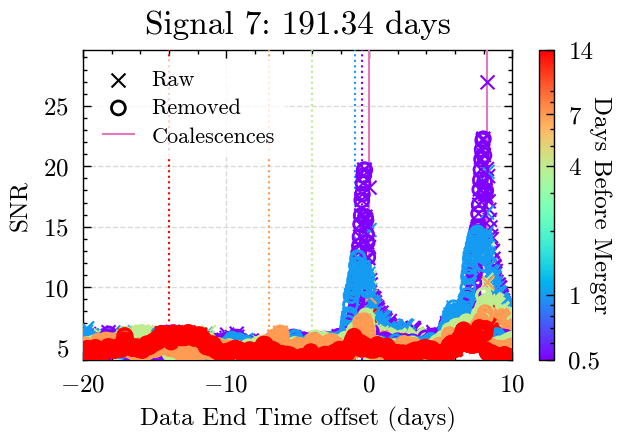

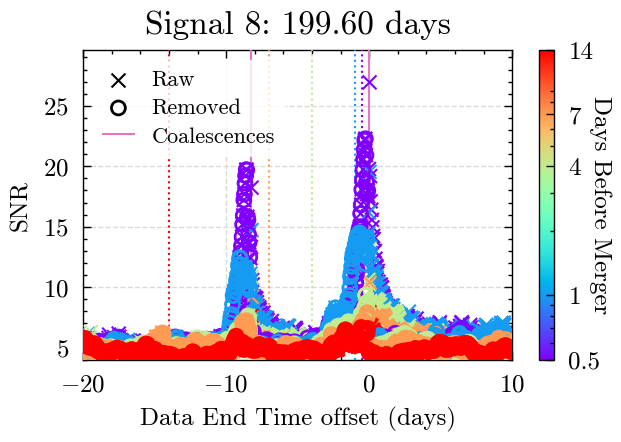

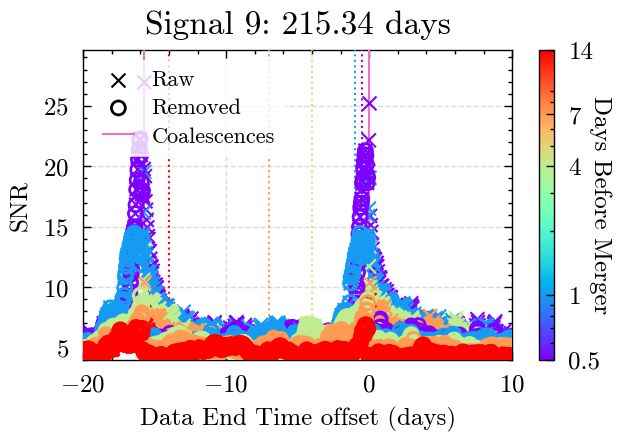

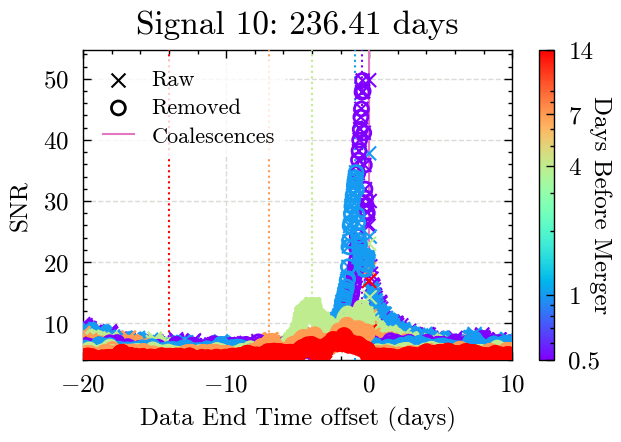

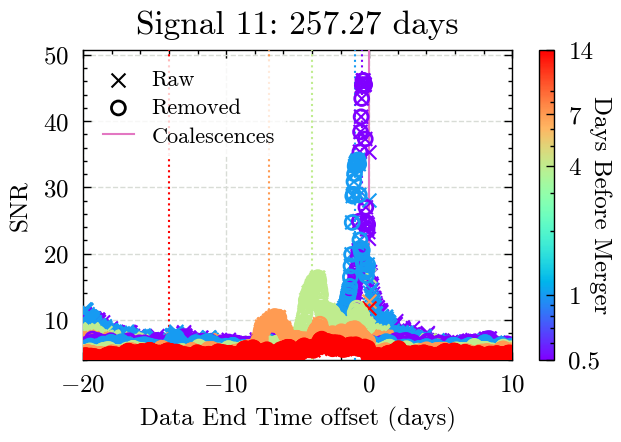

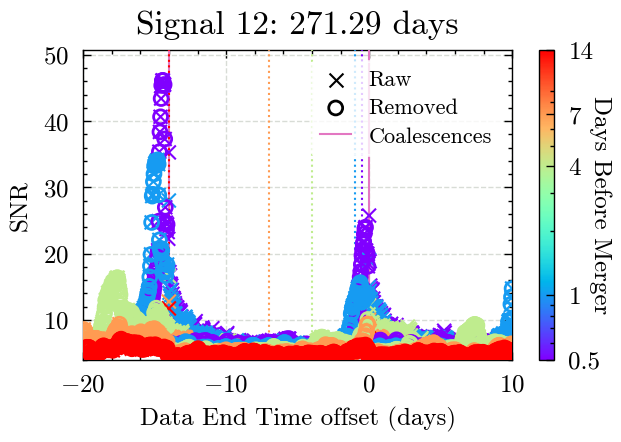

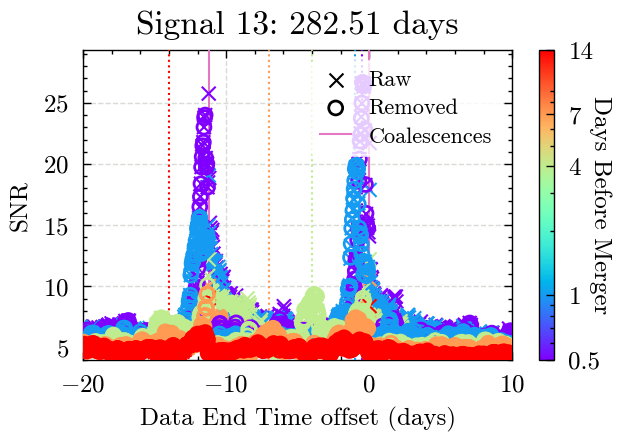

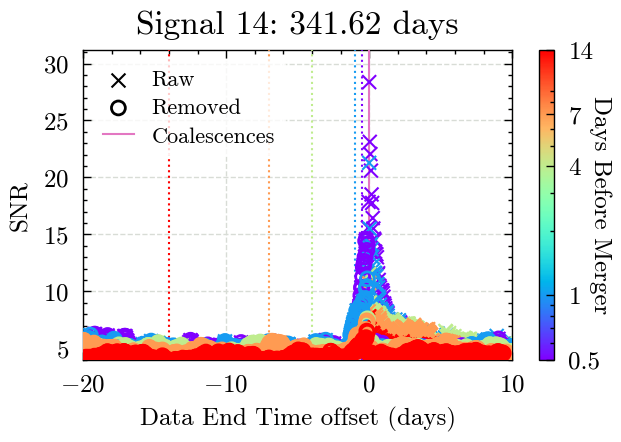

In [ ]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_model, _ = plotting_utils.plot_around_time(
        results_one=results_model_raw,
        results_two=results_model_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-20,
        end_time_offset=10,
        times_before=times_before,
        signal_number=i,
        predicted_time=False,
        legend_loc='upper right' if i in [5,12,13] else 'upper left'
    )

## Estimated PSD - forecast time

Raw/removed plots, but with the estimated PSD instead

### Estimated PSD - forecast time

Raw/removed plots, but with the estimated PSD instead

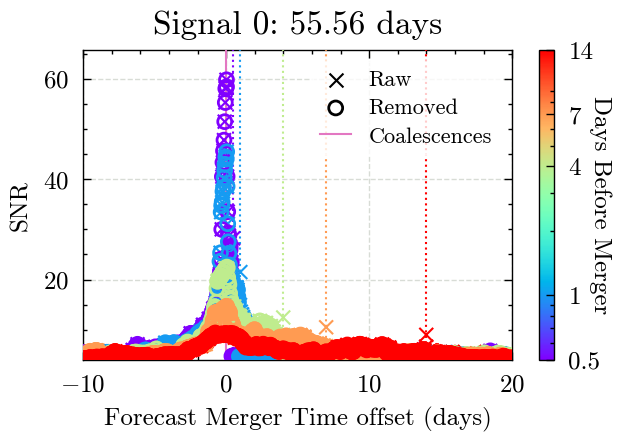

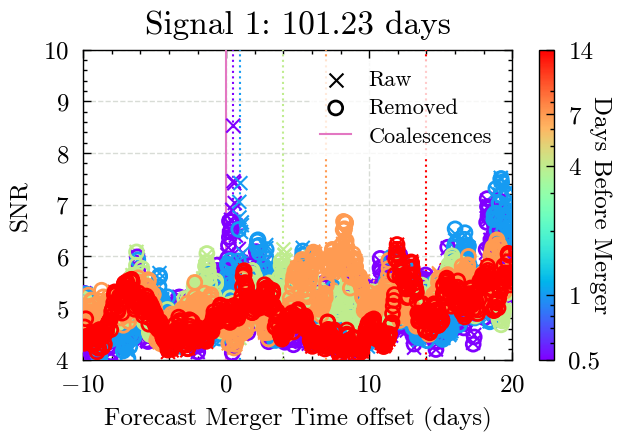

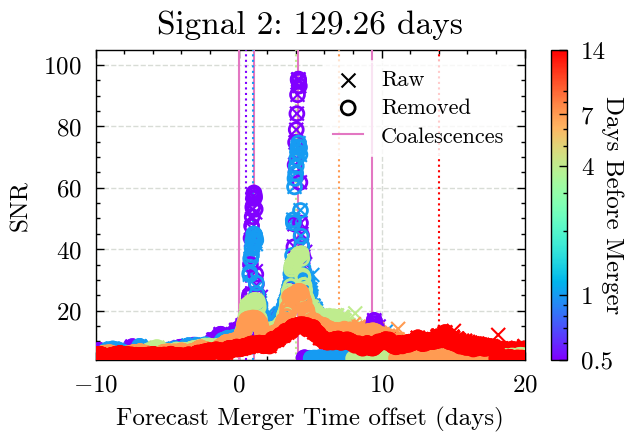

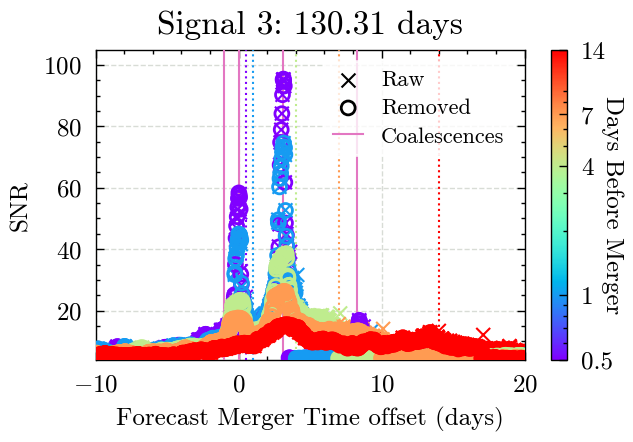

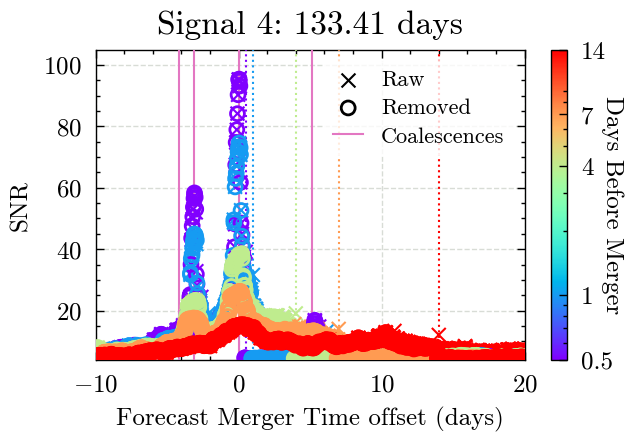

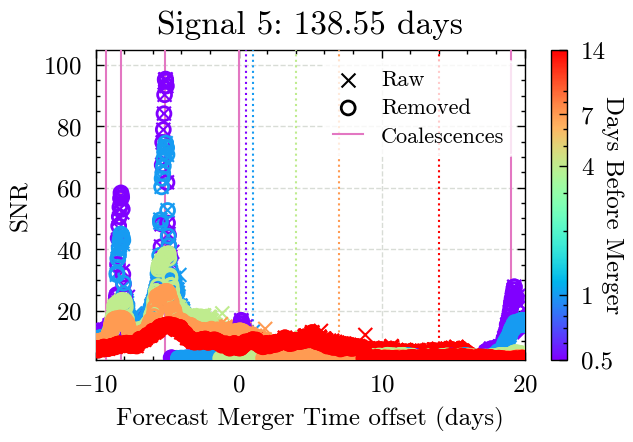

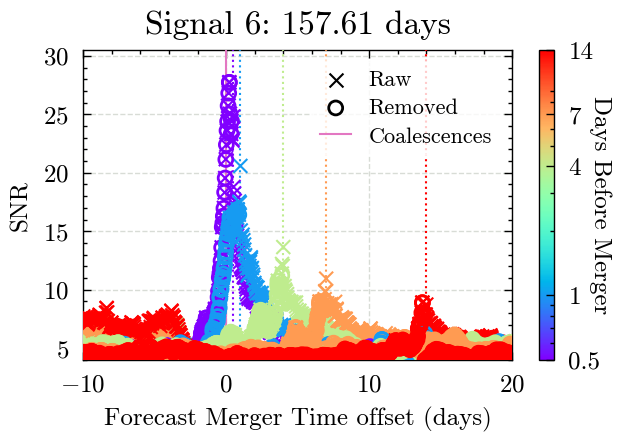

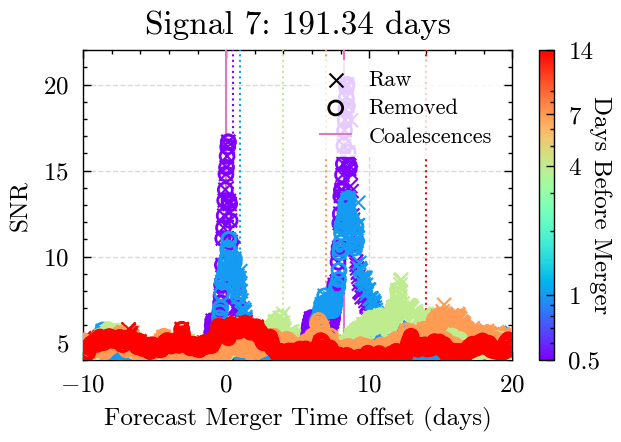

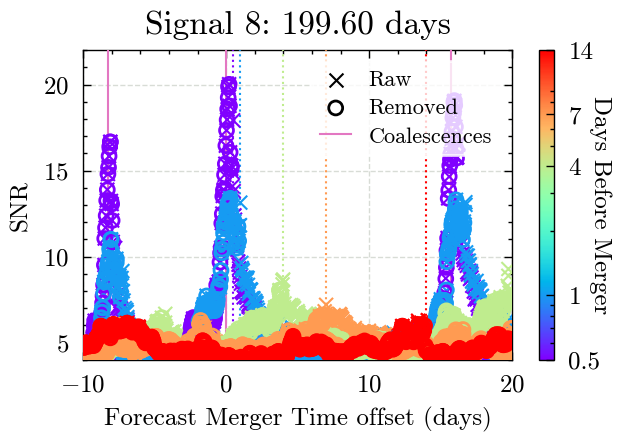

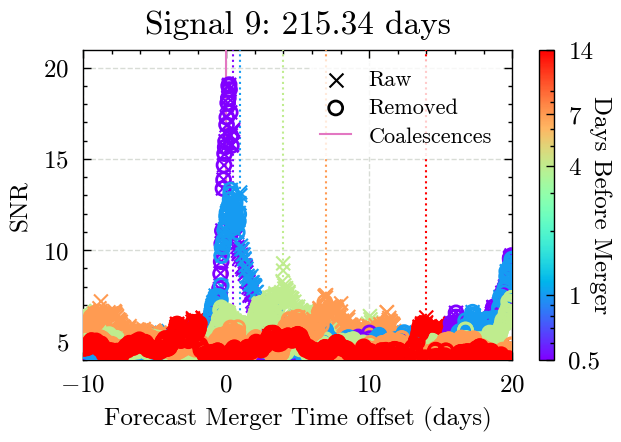

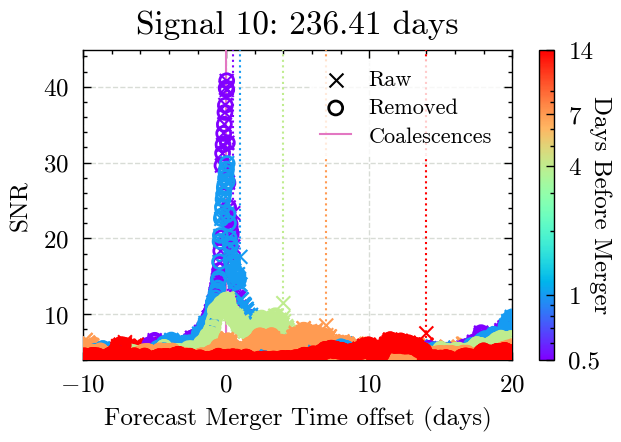

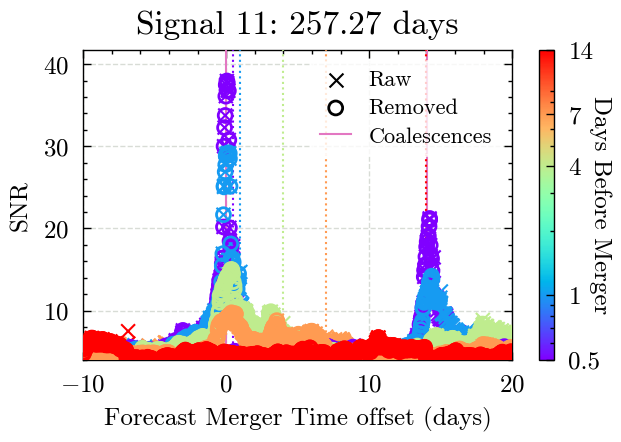

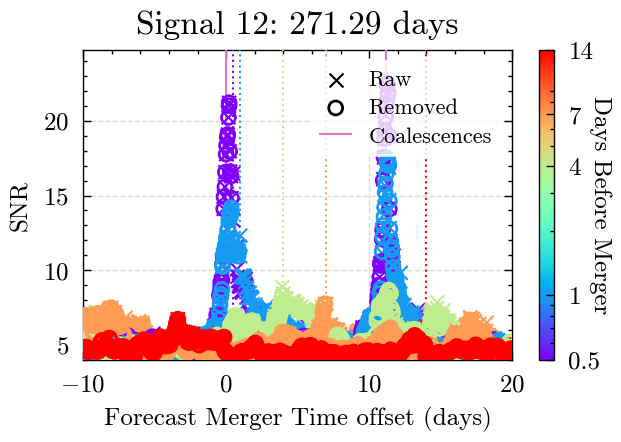

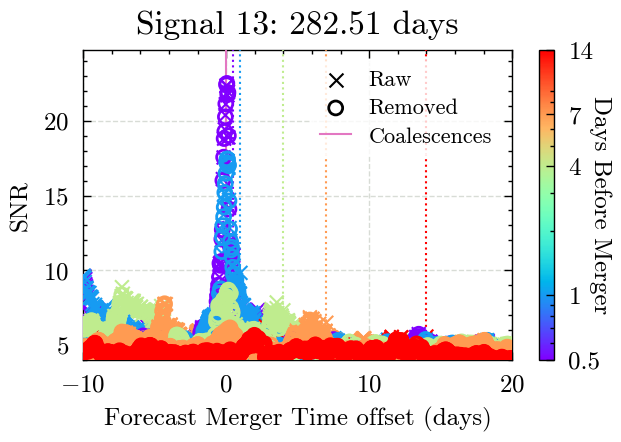

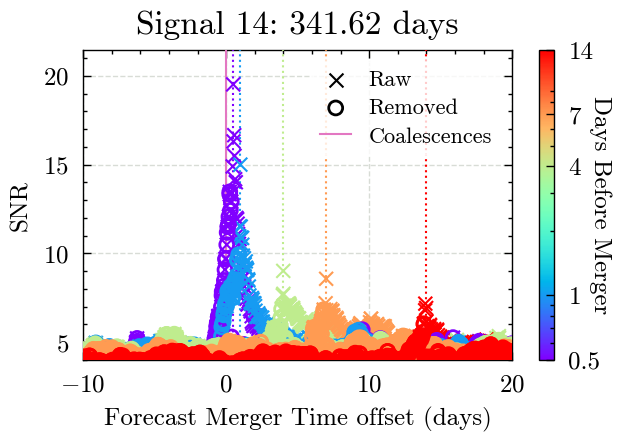

In [ ]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_estimate, _ = plotting_utils.plot_around_time(
        results_one=results_estimate_raw,
        results_two=results_estimate_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-10,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i,
        legend_loc='upper right'
    )

# Comparing estimated to model PSD

## Comparing estimated to model PSD

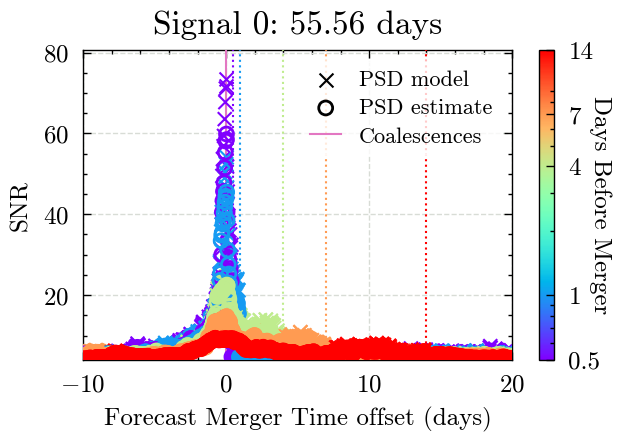

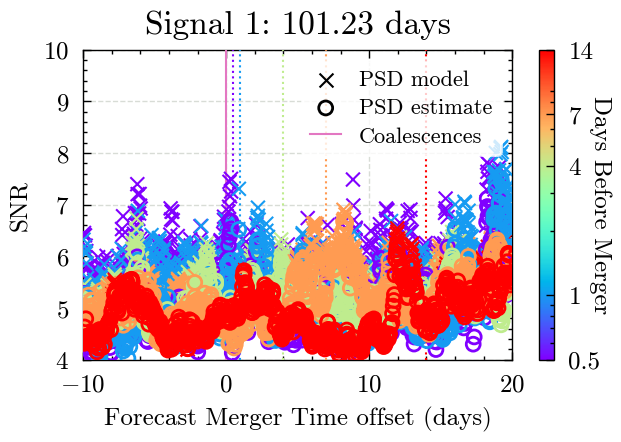

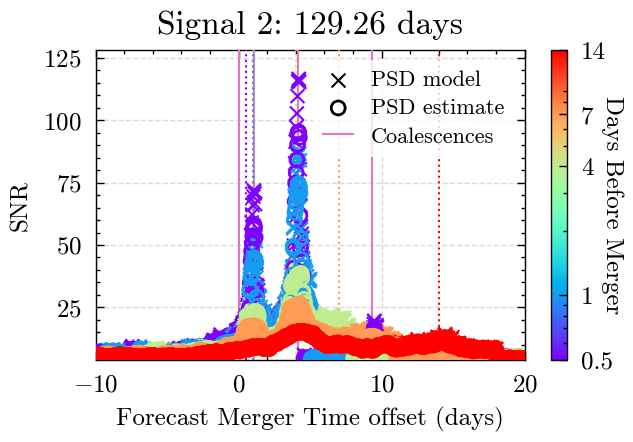

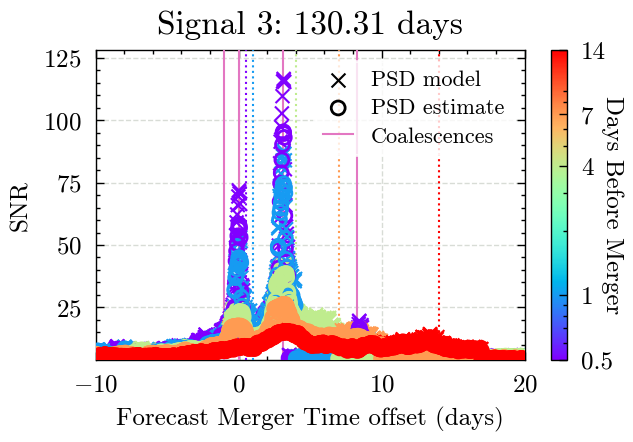

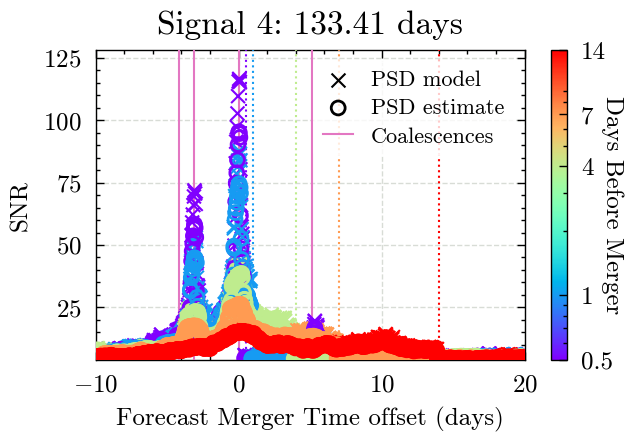

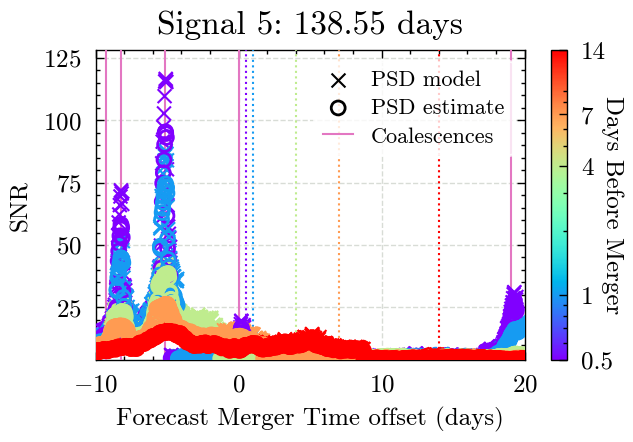

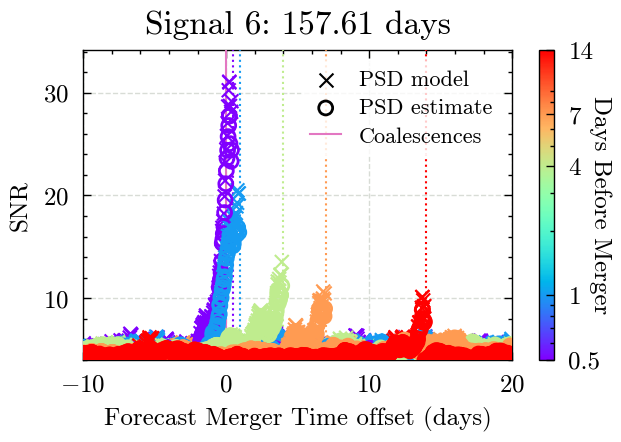

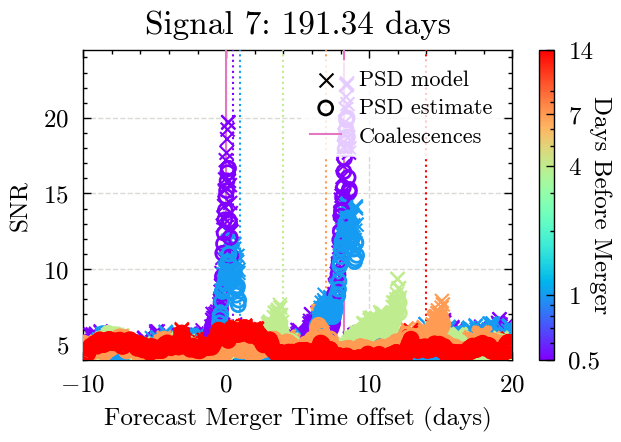

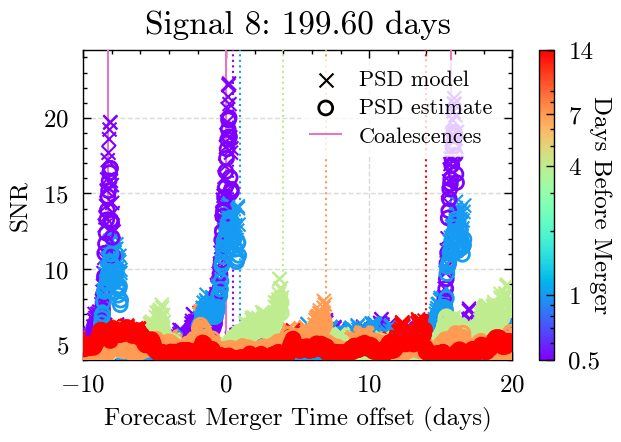

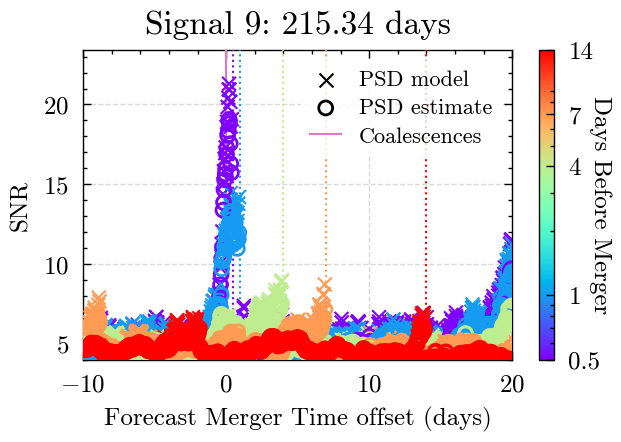

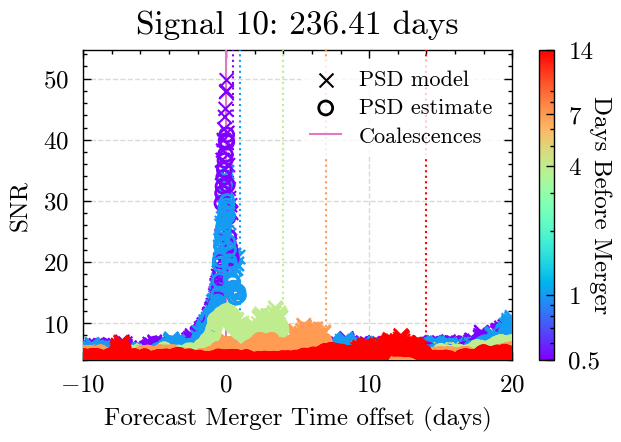

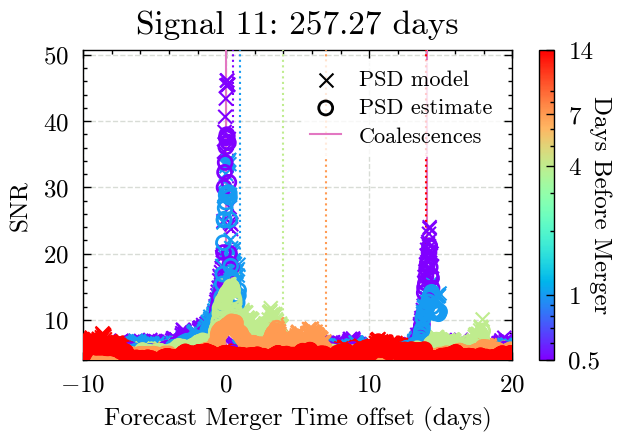

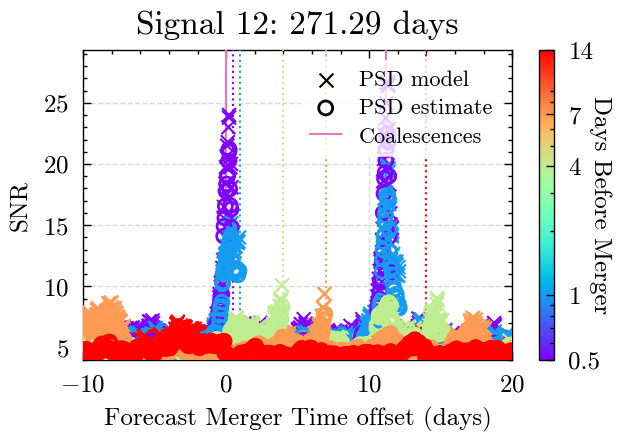

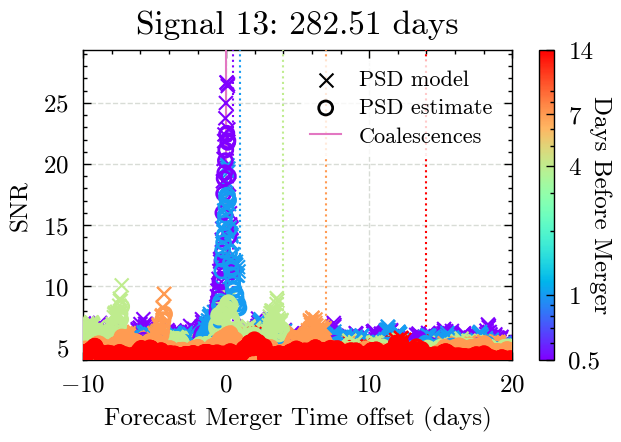

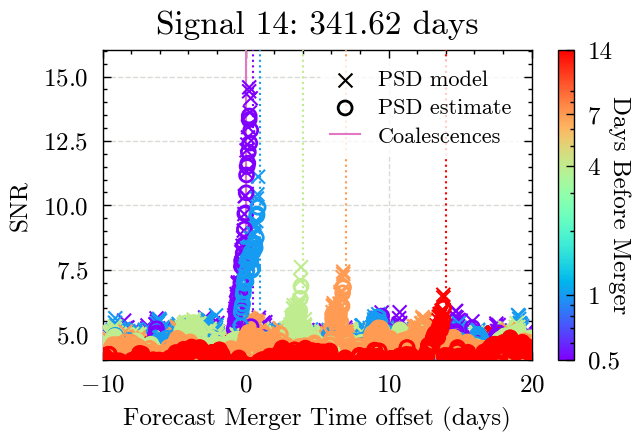

In [ ]:
for i, truth_time_s in enumerate(truth_times_s):
    if i in [8,11]:
        legend_loc = 'upper center'
    else:
        legend_loc = 'upper right'
    fig_psd_comparison, _ = plotting_utils.plot_around_time(
        results_one=results_model_remove,
        results_two=results_estimate_remove,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-10,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i,
        label_one='PSD model',
        label_two='PSD estimate',
        legend_loc='upper left' if i in [] else 'upper right'
    )